# Tugas Take-Home Sesi 05 — Advanced CNNs & Transfer Learning
## Bagian B: Eksperimen Praktik — Transfer Learning untuk Klasifikasi Citra dengan Data Terbatas

**Dataset:** Oxford-IIIT Pet (subset 10 kelas, ~2.000 citra)
**Arsitektur utama:** ResNet-18 (ImageNet pretrained)
**Protokol:** input 224x224, normalisasi ImageNet, batch 32, AdamW, CrossEntropyLoss, early stopping, seed 42

Notebook ini mengeksekusi 5 kondisi eksperimen:

| Kode | Kondisi | Deskripsi |
|------|---------|-----------|
| B1 | Baseline from Scratch | ResNet-18 `weights=None`, dilatih dari inisialisasi acak |
| B2 | Feature Extraction | Backbone dibekukan, hanya `fc` yang dilatih |
| B3 | Progressive Fine-Tuning | Unfreeze `layer4` + `fc`, differential learning rate |
| B4 | Uji Kontrol Augmentasi | B3 dengan vs tanpa data augmentation |
| B5 | Arsitektur Pembanding (bonus) | EfficientNet-B0 & MobileNetV3-Small |

Seluruh metrik otomatis dicatat ke `logs/metrics.csv` dan `logs/metrics.json` sebagai artefak verifikasi.

## 0. Instalasi Dependensi (jalankan di Google Colab)

In [ ]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 1. Setup & Reproduksibilitas (seed = 42)

In [2]:
import os
import json
import time
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import OxfordIIITPet
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinisme (sedikit mengorbankan kecepatan demi keterulangan)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Direktori artefak
LOG_DIR = Path('logs'); LOG_DIR.mkdir(exist_ok=True)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok=True)

# generator ter-seed untuk DataLoader shuffle yang reproducible
G = torch.Generator(); G.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

Device: cuda


## 2. Konfigurasi Global Eksperimen

In [3]:
# 10 kelas subset: 5 ras kucing + 5 ras anjing.
# Nama kelas Oxford-IIIT Pet: kucing diawali huruf kapital, anjing huruf kecil.
SELECTED_CLASSES = [
    # 5 ras kucing
    'Bengal', 'Bombay', 'Persian', 'Ragdoll', 'Siamese',
    # 5 ras anjing
    'beagle', 'boxer', 'chihuahua', 'pug', 'samoyed',
]
NUM_CLASSES = len(SELECTED_CLASSES)

BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 4            # early stopping patience (3-5 sesuai protokol)
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print('Jumlah kelas:', NUM_CLASSES)
print('Kelas:', SELECTED_CLASSES)

Jumlah kelas: 10
Kelas: ['Bengal', 'Bombay', 'Persian', 'Ragdoll', 'Siamese', 'beagle', 'boxer', 'chihuahua', 'pug', 'samoyed']


## 3. Dataset Oxford-IIIT Pet + Subset 10 Kelas + Split Stratified 70/15/15

Augmentasi hanya diterapkan pada train set. Validation & test set deterministik (resize + center crop + normalisasi) untuk mencegah kebocoran dan menjaga evaluasi yang adil.

In [4]:
# Transform train DENGAN augmentasi
train_tf_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform train TANPA augmentasi (untuk uji kontrol B4 skenario 1)
train_tf_noaug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform evaluasi (val/test) - deterministik, TANPA augmentasi
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# Unduh dataset penuh (trainval + test digabung lalu di-split ulang secara stratified).
# target_types='category' -> label integer 0..36.
full_trainval = OxfordIIITPet(root=str(DATA_DIR), split='trainval', target_types='category', download=True)
full_test = OxfordIIITPet(root=str(DATA_DIR), split='test', target_types='category', download=True)

# Nama kelas asli dari dataset (37 kelas)
ORIG_CLASSES = full_trainval.classes
print('Total kelas dataset:', len(ORIG_CLASSES))
print('Contoh nama kelas dataset:', ORIG_CLASSES[:5], '...')

# Pencocokan case-insensitive: nama kelas di torchvision bisa Title Case
# (mis. 'Beagle'), sementara daftar pilihan kita mungkin lowercase.
# Kita samakan lewat lowercase lalu simpan NAMA KANONIK dari dataset.
lower_to_orig = {c.lower(): i for i, c in enumerate(ORIG_CLASSES)}
missing = [n for n in SELECTED_CLASSES if n.lower() not in lower_to_orig]
assert not missing, f'Kelas tidak ditemukan di dataset: {missing}\nTersedia: {ORIG_CLASSES}'

# Perbarui SELECTED_CLASSES ke nama kanonik dataset (urutan tetap)
SELECTED_CLASSES = [ORIG_CLASSES[lower_to_orig[n.lower()]] for n in SELECTED_CLASSES]

# Peta nama kelas terpilih -> indeks asli
name_to_orig = {name: ORIG_CLASSES.index(name) for name in SELECTED_CLASSES}
orig_to_new = {orig: new for new, (name, orig) in enumerate(name_to_orig.items())}
print('Mapping kelas terpilih -> label baru:')
for name, orig in name_to_orig.items():
    print(f'  {name:14s} orig={orig:2d} -> new={orig_to_new[orig]}')

100%|██████████| 792M/792M [00:40<00:00, 19.8MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.64MB/s]


Total kelas dataset: 37
Contoh nama kelas dataset: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle'] ...
Mapping kelas terpilih -> label baru:
  Bengal         orig= 5 -> new=0
  Bombay         orig= 7 -> new=1
  Persian        orig=23 -> new=2
  Ragdoll        orig=26 -> new=3
  Siamese        orig=32 -> new=4
  Beagle         orig= 4 -> new=5
  Boxer          orig= 8 -> new=6
  Chihuahua      orig=10 -> new=7
  Pug            orig=25 -> new=8
  Samoyed        orig=29 -> new=9


In [6]:
class PetSubset(torch.utils.data.Dataset):
    """Membungkus Oxford-IIIT Pet: filter ke kelas terpilih, remap label 0..9,
    dan terapkan transform yang bisa diganti (train/eval)."""
    def __init__(self, base_dataset, indices, orig_to_new, transform=None):
        self.base = base_dataset
        self.indices = indices
        self.orig_to_new = orig_to_new
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img, orig_label = self.base[idx]  # img: PIL, orig_label: int
        label = self.orig_to_new[orig_label]
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def set_transform(self, transform):
        self.transform = transform

In [7]:
# Kumpulkan semua sampel (trainval + test) dari kelas terpilih beserta labelnya,
# lalu split ulang stratified 70/15/15.
selected_orig = set(name_to_orig.values())

def collect(dataset):
    items = []  # (dataset_ref, index, orig_label)
    # _labels tersedia di torchvision OxfordIIITPet untuk akses cepat tanpa load gambar
    labels = dataset._labels
    for idx, lab in enumerate(labels):
        if lab in selected_orig:
            items.append((idx, lab))
    return items

# Gabungkan kedua split lalu buat satu dataset gabungan via ConcatDataset-like manual.
from torch.utils.data import ConcatDataset
combined = ConcatDataset([full_trainval, full_test])

# Bangun daftar label gabungan untuk stratifikasi
combined_labels = list(full_trainval._labels) + list(full_test._labels)

sel_indices = [i for i, lab in enumerate(combined_labels) if lab in selected_orig]
sel_labels = [combined_labels[i] for i in sel_indices]
print('Total citra pada 10 kelas terpilih:', len(sel_indices))

# Split 70% train, 30% temp -> lalu temp dibagi 50/50 jadi 15% val + 15% test
train_idx, temp_idx, train_lab, temp_lab = train_test_split(
    sel_indices, sel_labels, test_size=0.30, stratify=sel_labels, random_state=SEED)
val_idx, test_idx, val_lab, test_lab = train_test_split(
    temp_idx, temp_lab, test_size=0.50, stratify=temp_lab, random_state=SEED)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Total citra pada 10 kelas terpilih: 1982
Train: 1387 | Val: 297 | Test: 298


In [8]:
# Verifikasi distribusi kelas (stratified harus seimbang antar split)
def dist(labels):
    s = pd.Series([orig_to_new[l] for l in labels]).value_counts().sort_index()
    s.index = [SELECTED_CLASSES[i] for i in s.index]
    return s

dist_df = pd.DataFrame({'train': dist(train_lab), 'val': dist(val_lab), 'test': dist(test_lab)}).fillna(0).astype(int)
print(dist_df)
dist_df.to_csv(LOG_DIR / 'class_distribution.csv')

           train  val  test
Bengal       140   30    30
Bombay       129   27    28
Persian      140   30    30
Ragdoll      140   30    30
Siamese      139   30    30
Beagle       140   30    30
Boxer        139   30    30
Chihuahua    140   30    30
Pug          140   30    30
Samoyed      140   30    30


In [9]:
def make_loaders(train_transform):
    """Bangun train/val/test loader. train_transform bisa aug / no-aug."""
    train_ds = PetSubset(combined, train_idx, orig_to_new, transform=train_transform)
    val_ds = PetSubset(combined, val_idx, orig_to_new, transform=eval_tf)
    test_ds = PetSubset(combined, test_idx, orig_to_new, transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, worker_init_fn=seed_worker,
                              generator=G, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

# Loader default (dengan augmentasi) untuk B1-B3
train_loader, val_loader, test_loader = make_loaders(train_tf_aug)
print('Batch train:', len(train_loader), '| val:', len(val_loader), '| test:', len(test_loader))

Batch train: 44 | val: 10 | test: 10


## 4. Model Builder (ResNet-18 untuk B1/B2/B3, arsitektur pembanding untuk B5)

In [10]:
def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def build_resnet18(mode: str):
    """mode in {'scratch','feature_extraction','finetune'}"""
    if mode == 'scratch':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if mode == 'feature_extraction':
        for p in model.parameters():
            p.requires_grad = False

    # Ganti classifier head
    in_feat = model.fc.in_features
    model.fc = nn.Linear(in_feat, NUM_CLASSES)

    if mode == 'finetune':
        # Bekukan semua dulu, lalu buka layer4 + fc
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    return model


def build_optimizer(model, mode: str):
    """Kembalikan optimizer AdamW + catatan LR per kelompok parameter."""
    if mode == 'finetune':
        param_groups = [
            {'params': model.layer4.parameters(), 'lr': 1e-4},
            {'params': model.fc.parameters(), 'lr': 1e-3},
        ]
        lr_note = 'layer4=1e-4, fc=1e-3'
        opt = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    elif mode == 'feature_extraction':
        opt = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        lr_note = 'fc=1e-3'
    else:  # scratch
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        lr_note = 'all=1e-3'
    return opt, lr_note

## 5. Engine Training + Early Stopping + Logging Metrik

Setiap run mencatat: trainable params, LR per group, epoch konvergen, durasi pelatihan, akurasi validasi akhir, dan Macro F1 pada test set. Hasil disimpan ke `logs/metrics.csv` dan `logs/metrics.json`.

In [11]:
criterion = nn.CrossEntropyLoss()
RESULTS = []       # ringkasan tiap run
HISTORIES = {}     # kurva loss/acc per run


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    all_pred, all_true = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
        all_pred.extend(out.argmax(1).cpu().tolist())
        all_true.extend(y.cpu().tolist())
    avg_loss = total_loss / n
    acc = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average='macro')
    return avg_loss, acc, macro_f1, all_true, all_pred


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


def run_experiment(code, name, model, optimizer, lr_note,
                   train_loader, val_loader, test_loader,
                   max_epochs=MAX_EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)
    trainable, total = count_params(model)
    print(f'\n=== [{code}] {name} ===')
    print(f'Trainable params: {trainable:,} / {total:,} | LR: {lr_note}')

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.3f} '
              f'| val_loss {val_loss:.4f} acc {val_acc:.3f} f1 {val_f1:.3f}')

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stopping di epoch {epoch} (best epoch {best_epoch}).')
                break
    train_time = time.time() - t0

    # Muat bobot terbaik lalu evaluasi test set
    model.load_state_dict(best_state)
    _, best_val_acc, best_val_f1, _, _ = evaluate(model, val_loader)
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader)

    record = {
        'code': code,
        'name': name,
        'trainable_params': int(trainable),
        'total_params': int(total),
        'lr': lr_note,
        'epochs_run': len(history['train_loss']),
        'best_epoch': best_epoch,
        'train_time_sec': round(train_time, 1),
        'val_acc': round(best_val_acc, 4),
        'val_macro_f1': round(best_val_f1, 4),
        'test_acc': round(test_acc, 4),
        'test_macro_f1': round(test_f1, 4),
    }
    RESULTS.append(record)
    HISTORIES[code] = history
    print(f'  -> test_acc {test_acc:.4f} | test_macro_f1 {test_f1:.4f} | waktu {train_time:.1f}s')
    return model, record, (y_true, y_pred)


def save_logs():
    df = pd.DataFrame(RESULTS)
    df.to_csv(LOG_DIR / 'metrics.csv', index=False)
    with open(LOG_DIR / 'metrics.json', 'w') as f:
        json.dump({'results': RESULTS, 'histories': HISTORIES}, f, indent=2)
    print('Log tersimpan ke logs/metrics.csv & logs/metrics.json')
    return df

## 6. B1 — Baseline from Scratch (`weights=None`)

In [12]:
set_seed(SEED)
m_b1 = build_resnet18('scratch')
opt_b1, lr_b1 = build_optimizer(m_b1, 'scratch')
model_b1, rec_b1, _ = run_experiment('B1', 'Baseline from Scratch', m_b1, opt_b1, lr_b1,
                                     train_loader, val_loader, test_loader)
save_logs()


=== [B1] Baseline from Scratch ===
Trainable params: 11,181,642 / 11,181,642 | LR: all=1e-3
  Epoch 01 | train_loss 2.2273 acc 0.214 | val_loss 2.1367 acc 0.249 f1 0.177
  Epoch 02 | train_loss 1.9642 acc 0.266 | val_loss 2.2702 acc 0.259 f1 0.198
  Epoch 03 | train_loss 1.8892 acc 0.315 | val_loss 2.6314 acc 0.236 f1 0.178
  Epoch 04 | train_loss 1.7668 acc 0.359 | val_loss 1.8879 acc 0.354 f1 0.300
  Epoch 05 | train_loss 1.6783 acc 0.399 | val_loss 2.6342 acc 0.306 f1 0.268
  Epoch 06 | train_loss 1.6023 acc 0.430 | val_loss 1.7467 acc 0.401 f1 0.392
  Epoch 07 | train_loss 1.5510 acc 0.453 | val_loss 1.8029 acc 0.343 f1 0.319
  Epoch 08 | train_loss 1.4545 acc 0.489 | val_loss 2.0907 acc 0.350 f1 0.313
  Epoch 09 | train_loss 1.4035 acc 0.503 | val_loss 1.5810 acc 0.434 f1 0.428
  Epoch 10 | train_loss 1.2980 acc 0.572 | val_loss 1.7656 acc 0.444 f1 0.436
  Epoch 11 | train_loss 1.3305 acc 0.527 | val_loss 2.8647 acc 0.323 f1 0.302
  Epoch 12 | train_loss 1.2127 acc 0.575 | val_lo

,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992


## 7. B2 — Feature Extraction (backbone beku, hanya `fc`)

Verifikasi: trainable params ResNet-18 di mode ini seharusnya `512*10 + 10 = 5.130`.

In [13]:
set_seed(SEED)
m_b2 = build_resnet18('feature_extraction')
opt_b2, lr_b2 = build_optimizer(m_b2, 'feature_extraction')
tr_b2, _ = count_params(m_b2)
assert tr_b2 == 5130, f'Trainable params B2 harus 5130, ternyata {tr_b2}'
model_b2, rec_b2, _ = run_experiment('B2', 'Feature Extraction', m_b2, opt_b2, lr_b2,
                                     train_loader, val_loader, test_loader)
save_logs()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]



=== [B2] Feature Extraction ===
Trainable params: 5,130 / 11,181,642 | LR: fc=1e-3
  Epoch 01 | train_loss 1.4229 acc 0.621 | val_loss 0.6081 acc 0.906 f1 0.905
  Epoch 02 | train_loss 0.5514 acc 0.909 | val_loss 0.3233 acc 0.946 f1 0.946
  Epoch 03 | train_loss 0.3806 acc 0.922 | val_loss 0.2384 acc 0.949 f1 0.949
  Epoch 04 | train_loss 0.2958 acc 0.933 | val_loss 0.2069 acc 0.946 f1 0.946
  Epoch 05 | train_loss 0.2507 acc 0.949 | val_loss 0.1785 acc 0.953 f1 0.953
  Epoch 06 | train_loss 0.2127 acc 0.961 | val_loss 0.1785 acc 0.953 f1 0.953
  Epoch 07 | train_loss 0.2102 acc 0.959 | val_loss 0.1644 acc 0.963 f1 0.962
  Epoch 08 | train_loss 0.2009 acc 0.947 | val_loss 0.1580 acc 0.960 f1 0.959
  Epoch 09 | train_loss 0.1639 acc 0.965 | val_loss 0.1384 acc 0.960 f1 0.959
  Epoch 10 | train_loss 0.1526 acc 0.959 | val_loss 0.1405 acc 0.963 f1 0.963
  Epoch 11 | train_loss 0.1503 acc 0.963 | val_loss 0.1269 acc 0.956 f1 0.956
  Epoch 12 | train_loss 0.1335 acc 0.973 | val_loss 0.1279

,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664


## 8. B3 — Progressive Fine-Tuning (unfreeze `layer4` + `fc`, differential LR)

In [14]:
set_seed(SEED)
m_b3 = build_resnet18('finetune')
opt_b3, lr_b3 = build_optimizer(m_b3, 'finetune')
model_b3, rec_b3, b3_preds = run_experiment('B3', 'Progressive Fine-Tuning', m_b3, opt_b3, lr_b3,
                                            train_loader, val_loader, test_loader)
save_logs()


=== [B3] Progressive Fine-Tuning ===
Trainable params: 8,398,858 / 11,181,642 | LR: layer4=1e-4, fc=1e-3
  Epoch 01 | train_loss 0.7222 acc 0.797 | val_loss 0.1305 acc 0.970 f1 0.969
  Epoch 02 | train_loss 0.1442 acc 0.962 | val_loss 0.1246 acc 0.970 f1 0.970
  Epoch 03 | train_loss 0.0956 acc 0.977 | val_loss 0.1181 acc 0.973 f1 0.973
  Epoch 04 | train_loss 0.0522 acc 0.987 | val_loss 0.1229 acc 0.970 f1 0.970
  Epoch 05 | train_loss 0.0319 acc 0.996 | val_loss 0.1069 acc 0.973 f1 0.973
  Epoch 06 | train_loss 0.0196 acc 0.997 | val_loss 0.1015 acc 0.980 f1 0.980
  Epoch 07 | train_loss 0.0210 acc 0.997 | val_loss 0.1131 acc 0.970 f1 0.969
  Epoch 08 | train_loss 0.0165 acc 0.996 | val_loss 0.1146 acc 0.973 f1 0.973
  Epoch 09 | train_loss 0.0199 acc 0.995 | val_loss 0.1362 acc 0.949 f1 0.949
  Epoch 10 | train_loss 0.0119 acc 0.999 | val_loss 0.1305 acc 0.966 f1 0.966
  Early stopping di epoch 10 (best epoch 6).
  -> test_acc 0.9732 | test_macro_f1 0.9733 | waktu 135.4s
Log tersim

,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733


## 9. B4 — Uji Kontrol Data Augmentation

Kita pilih kondisi **B3 (progressive fine-tuning)** lalu jalankan dalam dua skenario: tanpa augmentasi vs dengan augmentasi. Bandingkan selisih akurasi dan tingkat overfitting (gap train-val).

In [15]:
# B4a: TANPA augmentasi
train_loader_noaug, val_loader_b4, test_loader_b4 = make_loaders(train_tf_noaug)
set_seed(SEED)
m_b4a = build_resnet18('finetune')
opt_b4a, lr_b4a = build_optimizer(m_b4a, 'finetune')
model_b4a, rec_b4a, _ = run_experiment('B4a', 'Fine-Tuning TANPA Augmentasi', m_b4a, opt_b4a, lr_b4a,
                                       train_loader_noaug, val_loader_b4, test_loader_b4)
save_logs()


=== [B4a] Fine-Tuning TANPA Augmentasi ===
Trainable params: 8,398,858 / 11,181,642 | LR: layer4=1e-4, fc=1e-3
  Epoch 01 | train_loss 0.5914 acc 0.837 | val_loss 0.1453 acc 0.953 f1 0.952
  Epoch 02 | train_loss 0.0640 acc 0.994 | val_loss 0.1067 acc 0.973 f1 0.973
  Epoch 03 | train_loss 0.0235 acc 0.999 | val_loss 0.1029 acc 0.973 f1 0.973
  Epoch 04 | train_loss 0.0138 acc 0.998 | val_loss 0.1014 acc 0.973 f1 0.973
  Epoch 05 | train_loss 0.0078 acc 1.000 | val_loss 0.1016 acc 0.970 f1 0.970
  Epoch 06 | train_loss 0.0063 acc 1.000 | val_loss 0.1065 acc 0.970 f1 0.969
  Epoch 07 | train_loss 0.0051 acc 1.000 | val_loss 0.1030 acc 0.973 f1 0.973
  Epoch 08 | train_loss 0.0099 acc 0.998 | val_loss 0.1087 acc 0.976 f1 0.976
  Early stopping di epoch 8 (best epoch 4).
  -> test_acc 0.9698 | test_macro_f1 0.9698 | waktu 73.1s
Log tersimpan ke logs/metrics.csv & logs/metrics.json


,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733
3,B4a,Fine-Tuning TANPA Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",8,4,73.1,0.9731,0.9728,0.9698,0.9698


In [16]:
# B4b: DENGAN augmentasi (identik dengan B3, dicatat ulang sebagai pembanding eksplisit B4)
train_loader_aug, val_loader_b4b, test_loader_b4b = make_loaders(train_tf_aug)
set_seed(SEED)
m_b4b = build_resnet18('finetune')
opt_b4b, lr_b4b = build_optimizer(m_b4b, 'finetune')
model_b4b, rec_b4b, _ = run_experiment('B4b', 'Fine-Tuning DENGAN Augmentasi', m_b4b, opt_b4b, lr_b4b,
                                       train_loader_aug, val_loader_b4b, test_loader_b4b)
save_logs()


=== [B4b] Fine-Tuning DENGAN Augmentasi ===
Trainable params: 8,398,858 / 11,181,642 | LR: layer4=1e-4, fc=1e-3
  Epoch 01 | train_loss 0.6645 acc 0.823 | val_loss 0.1188 acc 0.970 f1 0.970
  Epoch 02 | train_loss 0.1371 acc 0.969 | val_loss 0.1345 acc 0.960 f1 0.959
  Epoch 03 | train_loss 0.0842 acc 0.978 | val_loss 0.1198 acc 0.970 f1 0.969
  Epoch 04 | train_loss 0.0551 acc 0.988 | val_loss 0.1194 acc 0.973 f1 0.973
  Epoch 05 | train_loss 0.0438 acc 0.988 | val_loss 0.1185 acc 0.966 f1 0.966
  Epoch 06 | train_loss 0.0428 acc 0.987 | val_loss 0.1283 acc 0.963 f1 0.963
  Epoch 07 | train_loss 0.0232 acc 0.994 | val_loss 0.1199 acc 0.980 f1 0.980
  Epoch 08 | train_loss 0.0228 acc 0.995 | val_loss 0.1188 acc 0.980 f1 0.980
  Epoch 09 | train_loss 0.0150 acc 0.999 | val_loss 0.1124 acc 0.976 f1 0.976
  Epoch 10 | train_loss 0.0145 acc 0.996 | val_loss 0.1853 acc 0.960 f1 0.960
  Epoch 11 | train_loss 0.0099 acc 0.999 | val_loss 0.1511 acc 0.970 f1 0.969
  Epoch 12 | train_loss 0.007

,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733
3,B4a,Fine-Tuning TANPA Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",8,4,73.1,0.9731,0.9728,0.9698,0.9698
4,B4b,Fine-Tuning DENGAN Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",13,9,168.6,0.9764,0.9761,0.9698,0.9700


In [17]:
# Hitung generalization gap (train_acc akhir - val_acc akhir) untuk kedua skenario
def final_gap(code):
    h = HISTORIES[code]
    return round(h['train_acc'][-1] - h['val_acc'][-1], 4)

print('Generalization gap B4a (tanpa aug):', final_gap('B4a'))
print('Generalization gap B4b (dengan aug):', final_gap('B4b'))
print('Selisih test acc (aug - noaug):', round(rec_b4b['test_acc'] - rec_b4a['test_acc'], 4))

Generalization gap B4a (tanpa aug): 0.0214
Generalization gap B4b (dengan aug): 0.0443
Selisih test acc (aug - noaug): 0.0


## 10. B5 — Arsitektur Pembanding (Bonus): EfficientNet-B0 & MobileNetV3-Small

Konfigurasi terbaik (progressive fine-tuning + augmentasi) dijalankan pada arsitektur efisien. Bandingkan trade-off Macro F1, jumlah parameter, dan durasi komputasi.

In [18]:
def build_efficientnet_b0_finetune():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    in_feat = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_feat, NUM_CLASSES)
    # Unfreeze blok fitur terakhir + classifier (analog layer4+fc di ResNet)
    for p in model.features[-1].parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True
    opt = torch.optim.AdamW([
        {'params': model.features[-1].parameters(), 'lr': 1e-4},
        {'params': model.classifier.parameters(), 'lr': 1e-3},
    ], weight_decay=WEIGHT_DECAY)
    return model, opt, 'features[-1]=1e-4, classifier=1e-3'


def build_mobilenetv3_small_finetune():
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    in_feat = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_feat, NUM_CLASSES)
    for p in model.features[-1].parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True
    opt = torch.optim.AdamW([
        {'params': model.features[-1].parameters(), 'lr': 1e-4},
        {'params': model.classifier.parameters(), 'lr': 1e-3},
    ], weight_decay=WEIGHT_DECAY)
    return model, opt, 'features[-1]=1e-4, classifier=1e-3'

In [19]:
set_seed(SEED)
m_eff, opt_eff, lr_eff = build_efficientnet_b0_finetune()
model_eff, rec_eff, _ = run_experiment('B5-EffB0', 'EfficientNet-B0 Fine-Tuning', m_eff, opt_eff, lr_eff,
                                       train_loader, val_loader, test_loader)
save_logs()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 180MB/s]



=== [B5-EffB0] EfficientNet-B0 Fine-Tuning ===
Trainable params: 424,970 / 4,020,358 | LR: features[-1]=1e-4, classifier=1e-3
  Epoch 01 | train_loss 1.3748 acc 0.704 | val_loss 0.6307 acc 0.933 f1 0.933
  Epoch 02 | train_loss 0.5507 acc 0.902 | val_loss 0.3617 acc 0.946 f1 0.946
  Epoch 03 | train_loss 0.3780 acc 0.924 | val_loss 0.2679 acc 0.946 f1 0.946
  Epoch 04 | train_loss 0.3017 acc 0.934 | val_loss 0.2329 acc 0.949 f1 0.950
  Epoch 05 | train_loss 0.2386 acc 0.947 | val_loss 0.1985 acc 0.956 f1 0.956
  Epoch 06 | train_loss 0.2116 acc 0.952 | val_loss 0.1734 acc 0.960 f1 0.960
  Epoch 07 | train_loss 0.2158 acc 0.942 | val_loss 0.1731 acc 0.956 f1 0.956
  Epoch 08 | train_loss 0.1562 acc 0.965 | val_loss 0.1626 acc 0.960 f1 0.960
  Epoch 09 | train_loss 0.1482 acc 0.968 | val_loss 0.1525 acc 0.960 f1 0.960
  Epoch 10 | train_loss 0.1450 acc 0.963 | val_loss 0.1458 acc 0.966 f1 0.966
  Epoch 11 | train_loss 0.1169 acc 0.971 | val_loss 0.1366 acc 0.966 f1 0.967
  Epoch 12 | tr

,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733
3,B4a,Fine-Tuning TANPA Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",8,4,73.1,0.9731,0.9728,0.9698,0.9698
4,B4b,Fine-Tuning DENGAN Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",13,9,168.6,0.9764,0.9761,0.9698,0.9700
5,B5-EffB0,EfficientNet-B0 Fine-Tuning,424970,4020358,"features[-1]=1e-4, classifier=1e-3",26,22,345.5,0.9663,0.9666,0.9664,0.9664


In [20]:
set_seed(SEED)
m_mob, opt_mob, lr_mob = build_mobilenetv3_small_finetune()
model_mob, rec_mob, _ = run_experiment('B5-MobV3', 'MobileNetV3-Small Fine-Tuning', m_mob, opt_mob, lr_mob,
                                       train_loader, val_loader, test_loader)
save_logs()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 215MB/s]


=== [B5-MobV3] MobileNetV3-Small Fine-Tuning ===
Trainable params: 657,546 / 1,528,106 | LR: features[-1]=1e-4, classifier=1e-3


  Epoch 01 | train_loss 0.9013 acc 0.722 | val_loss 0.4404 acc 0.852 f1 0.847
  Epoch 02 | train_loss 0.3903 acc 0.861 | val_loss 0.3288 acc 0.886 f1 0.887
  Epoch 03 | train_loss 0.2878 acc 0.895 | val_loss 0.2351 acc 0.933 f1 0.934
  Epoch 04 | train_loss 0.2445 acc 0.925 | val_loss 0.2433 acc 0.936 f1 0.936
  Epoch 05 | train_loss 0.2134 acc 0.928 | val_loss 0.2048 acc 0.939 f1 0.939
  Epoch 06 | train_loss 0.2085 acc 0.931 | val_loss 0.2800 acc 0.916 f1 0.916
  Epoch 07 | train_loss 0.2127 acc 0.924 | val_loss 0.2206 acc 0.933 f1 0.933
  Epoch 08 | train_loss 0.1431 acc 0.955 | val_loss 0.2140 acc 0.936 f1 0.936
  Epoch 09 | train_loss 0.1137 acc 0.965 | val_loss 0.2478 acc 0.926 f1 0.926
  Early stopping di epoch 9 (best epoch 5).
  -> test_acc 0.9396 | test_macro_f1 0.9391 | waktu 116.8s
Log tersimpan ke logs/metrics.csv & logs/metrics.json


,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733
3,B4a,Fine-Tuning TANPA Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",8,4,73.1,0.9731,0.9728,0.9698,0.9698
4,B4b,Fine-Tuning DENGAN Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",13,9,168.6,0.9764,0.9761,0.9698,0.9700
5,B5-EffB0,EfficientNet-B0 Fine-Tuning,424970,4020358,"features[-1]=1e-4, classifier=1e-3",26,22,345.5,0.9663,0.9666,0.9664,0.9664
6,B5-MobV3,MobileNetV3-Small Fine-Tuning,657546,1528106,"features[-1]=1e-4, classifier=1e-3",9,5,116.8,0.9394,0.9388,0.9396,0.9391


## 11. C1 — Tabel Konsolidasi & Kurva Training vs Validation Loss

In [21]:
summary_df = save_logs()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
summary_df

Log tersimpan ke logs/metrics.csv & logs/metrics.json


,code,name,trainable_params,total_params,lr,epochs_run,best_epoch,train_time_sec,val_acc,val_macro_f1,test_acc,test_macro_f1
0,B1,Baseline from Scratch,11181642,11181642,all=1e-3,13,9,189.2,0.4343,0.4279,0.4094,0.3992
1,B2,Feature Extraction,5130,11181642,fc=1e-3,20,16,262.6,0.9697,0.9697,0.9664,0.9664
2,B3,Progressive Fine-Tuning,8398858,11181642,"layer4=1e-4, fc=1e-3",10,6,135.4,0.9798,0.9795,0.9732,0.9733
3,B4a,Fine-Tuning TANPA Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",8,4,73.1,0.9731,0.9728,0.9698,0.9698
4,B4b,Fine-Tuning DENGAN Augmentasi,8398858,11181642,"layer4=1e-4, fc=1e-3",13,9,168.6,0.9764,0.9761,0.9698,0.9700
5,B5-EffB0,EfficientNet-B0 Fine-Tuning,424970,4020358,"features[-1]=1e-4, classifier=1e-3",26,22,345.5,0.9663,0.9666,0.9664,0.9664
6,B5-MobV3,MobileNetV3-Small Fine-Tuning,657546,1528106,"features[-1]=1e-4, classifier=1e-3",9,5,116.8,0.9394,0.9388,0.9396,0.9391


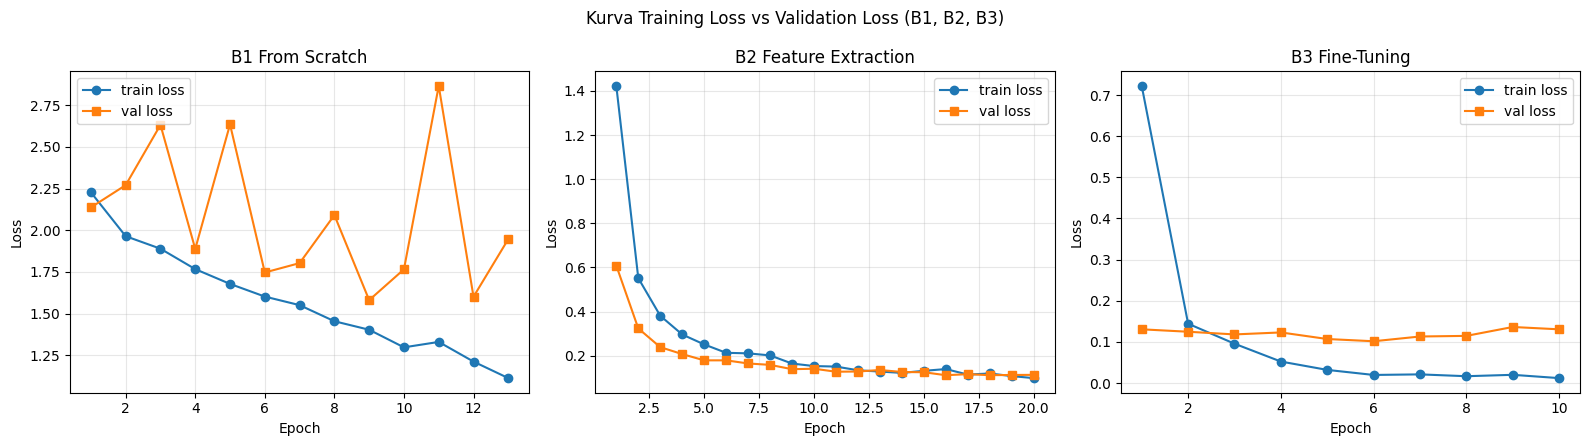

In [22]:
# Kurva train vs val loss untuk B1, B2, B3
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, code, title in zip(axes, ['B1', 'B2', 'B3'],
                           ['B1 From Scratch', 'B2 Feature Extraction', 'B3 Fine-Tuning']):
    h = HISTORIES[code]
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], 'o-', label='train loss')
    ax.plot(epochs, h['val_loss'], 's-', label='val loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Kurva Training Loss vs Validation Loss (B1, B2, B3)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'loss_curves_b1_b2_b3.png', dpi=150, bbox_inches='tight')
plt.show()

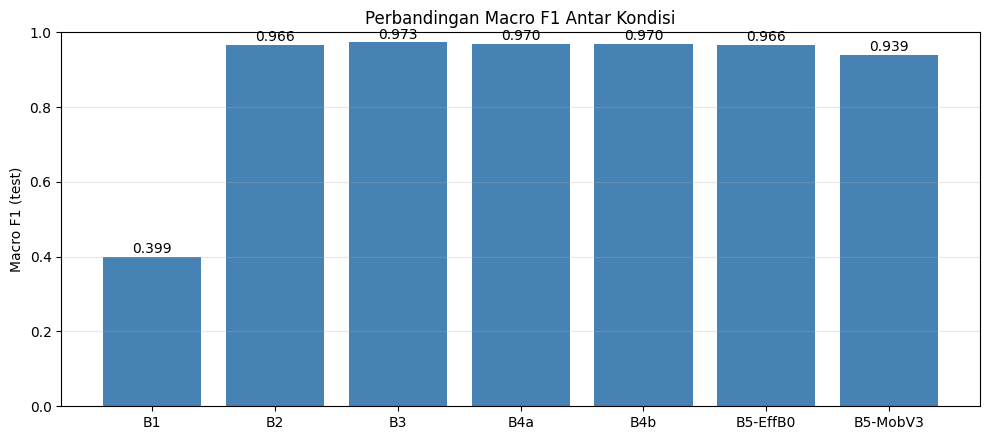

In [23]:
# Bar chart Macro F1 (test) semua kondisi
fig, ax = plt.subplots(figsize=(10, 4.5))
codes = [r['code'] for r in RESULTS]
f1s = [r['test_macro_f1'] for r in RESULTS]
bars = ax.bar(codes, f1s, color='steelblue')
ax.set_ylabel('Macro F1 (test)'); ax.set_title('Perbandingan Macro F1 Antar Kondisi')
ax.set_ylim(0, 1)
for b, v in zip(bars, f1s):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'macro_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. C3 — Failure Analysis (5–8 sampel misklasifikasi dari model terbaik)

In [24]:
# Pilih model terbaik berdasarkan test_macro_f1
best_rec = max(RESULTS, key=lambda r: r['test_macro_f1'])
print('Model terbaik:', best_rec['code'], best_rec['name'], '| Macro F1:', best_rec['test_macro_f1'])

BEST_MODELS = {
    'B1': model_b1, 'B2': model_b2, 'B3': model_b3,
    'B4a': model_b4a, 'B4b': model_b4b,
    'B5-EffB0': model_eff, 'B5-MobV3': model_mob,
}
best_model = BEST_MODELS[best_rec['code']].to(DEVICE).eval()

Model terbaik: B3 Progressive Fine-Tuning | Macro F1: 0.9733


In [25]:
# Kumpulkan prediksi test beserta confidence, cari yang salah
def denorm(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

mis = []  # (img_tensor, true, pred, conf)
with torch.no_grad():
    for x, y in test_loader_b4b if best_rec['code'] == 'B4b' else test_loader:
        x = x.to(DEVICE)
        probs = torch.softmax(best_model(x), dim=1)
        conf, pred = probs.max(1)
        for i in range(x.size(0)):
            if pred[i].item() != y[i].item():
                mis.append((x[i].cpu(), y[i].item(), pred[i].item(), conf[i].item()))
print('Jumlah misklasifikasi:', len(mis))

Jumlah misklasifikasi: 8


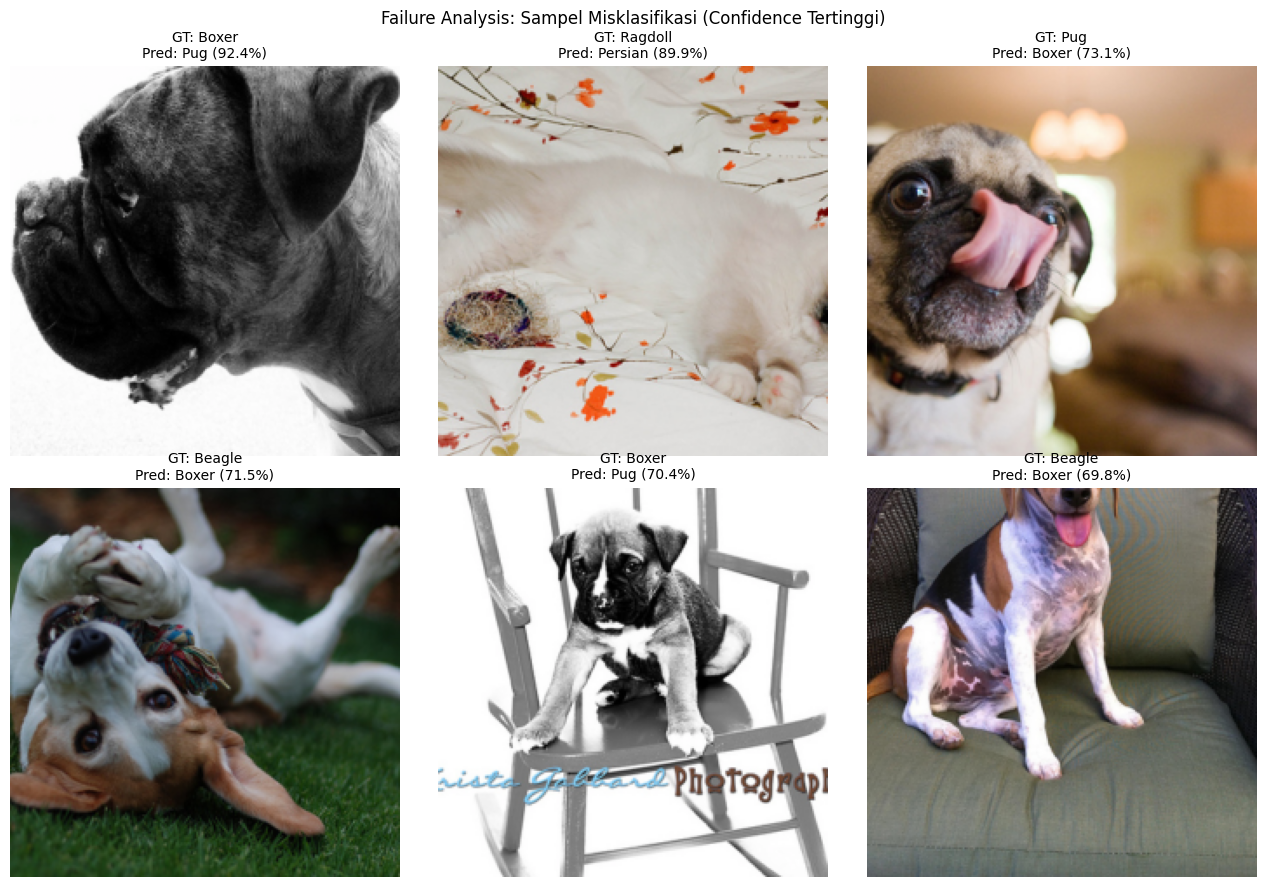

In [26]:
# Tampilkan 6 sampel misklasifikasi (confidence tertinggi = kesalahan paling 'yakin')
mis_sorted = sorted(mis, key=lambda t: -t[3])[:6]
n = len(mis_sorted)
cols = 3; rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(13, 4.5 * rows))
axes = np.array(axes).reshape(-1)
for ax, (img, t, p, c) in zip(axes, mis_sorted):
    ax.imshow(denorm(img))
    ax.set_title(f'GT: {SELECTED_CLASSES[t]}\nPred: {SELECTED_CLASSES[p]} ({c:.1%})', fontsize=10)
    ax.axis('off')
for ax in axes[n:]:
    ax.axis('off')
plt.suptitle('Failure Analysis: Sampel Misklasifikasi (Confidence Tertinggi)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

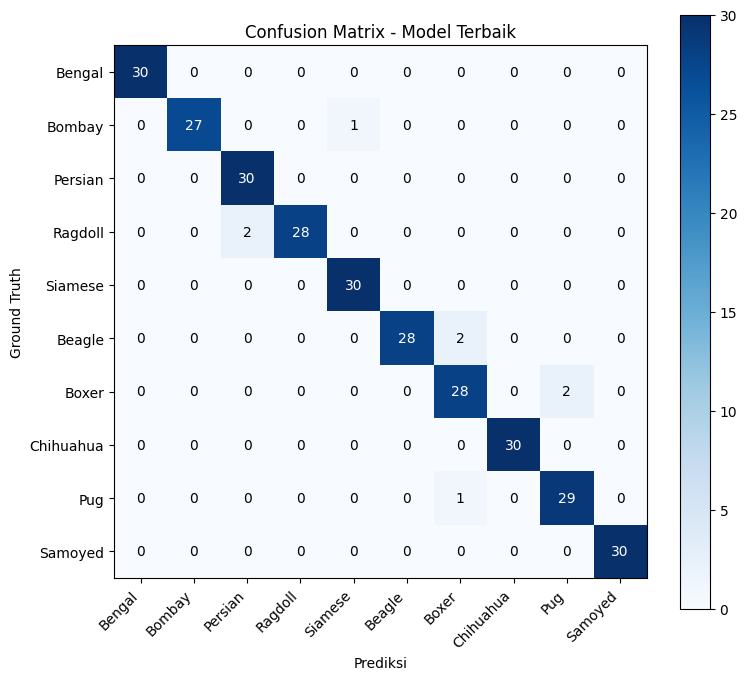

              precision    recall  f1-score   support

      Bengal       1.00      1.00      1.00        30
      Bombay       1.00      0.96      0.98        28
     Persian       0.94      1.00      0.97        30
     Ragdoll       1.00      0.93      0.97        30
     Siamese       0.97      1.00      0.98        30
      Beagle       1.00      0.93      0.97        30
       Boxer       0.90      0.93      0.92        30
   Chihuahua       1.00      1.00      1.00        30
         Pug       0.94      0.97      0.95        30
     Samoyed       1.00      1.00      1.00        30

    accuracy                           0.97       298
   macro avg       0.97      0.97      0.97       298
weighted avg       0.97      0.97      0.97       298



In [27]:
# Confusion matrix model terbaik + classification report
_, _, _, y_true_best, y_pred_best = evaluate(best_model,
    test_loader_b4b if best_rec['code'] == 'B4b' else test_loader)
cm = confusion_matrix(y_true_best, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(SELECTED_CLASSES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(SELECTED_CLASSES)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Ground Truth'); ax.set_title('Confusion Matrix - Model Terbaik')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_true_best, y_pred_best, target_names=SELECTED_CLASSES))

## 13. C5 — Grad-CAM pada `layer4` (Opsional / Nilai Tambah)

Membandingkan representasi aktivasi `layer4` ResNet-18 pada model feature extraction (B2) vs fine-tuned (B3) untuk melihat pergeseran fokus setelah adaptasi domain.

In [31]:
# Implementasi Grad-CAM ringkas (tanpa dependensi eksternal).
# Pada B2 (feature extraction) backbone dibekukan, jadi aktifkan requires_grad
# sementara untuk param target layer dan ambil gradien dari tensor activation.
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.activations = None
        for p in target_layer.parameters():
            p.requires_grad_(True)
        target_layer.register_forward_hook(self._fwd)

    def _fwd(self, module, inp, out):
        out.retain_grad()
        self.activations = out

    def __call__(self, x, class_idx=None):
        with torch.enable_grad():
            x = x.clone().requires_grad_(True)
            out = self.model(x)
            if class_idx is None:
                class_idx = out.argmax(1).item()
            self.model.zero_grad(set_to_none=True)
            out[0, class_idx].backward()
            grads = self.activations.grad
            acts = self.activations
            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam = (weights * acts).sum(1, keepdim=True)
            cam = torch.relu(cam)
            cam = torch.nn.functional.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
            cam = cam.squeeze().detach().cpu().numpy()
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


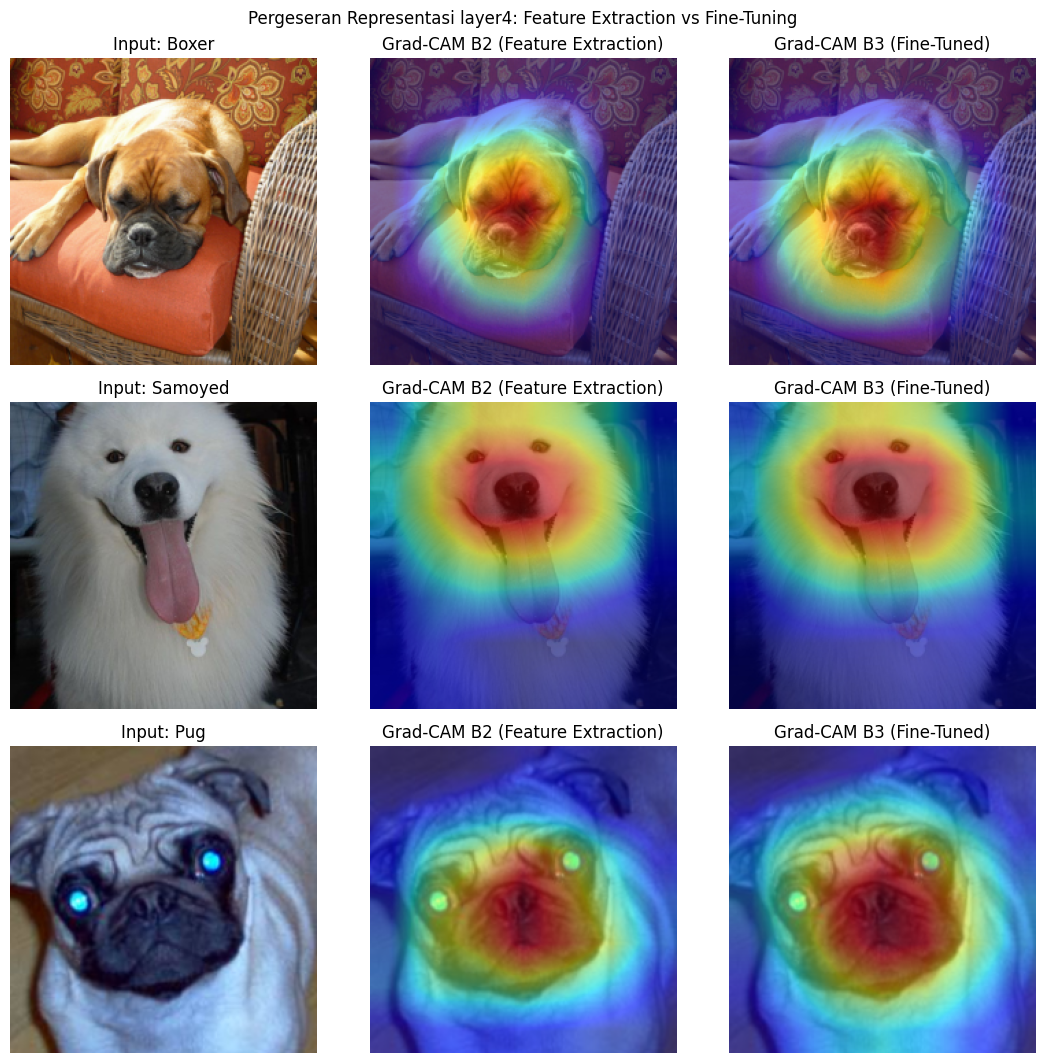

In [32]:
# Ambil 3 sampel test, bandingkan Grad-CAM B2 vs B3
sample_imgs, sample_labels = next(iter(test_loader))
n_show = 3
cam_b2 = GradCAM(model_b2.to(DEVICE), model_b2.layer4)
cam_b3 = GradCAM(model_b3.to(DEVICE), model_b3.layer4)

fig, axes = plt.subplots(n_show, 3, figsize=(11, 3.6 * n_show))
for r in range(n_show):
    img = sample_imgs[r:r+1].to(DEVICE)
    base = denorm(sample_imgs[r])
    cam2, _ = cam_b2(img)
    cam3, _ = cam_b3(img)
    axes[r, 0].imshow(base); axes[r, 0].set_title(f'Input: {SELECTED_CLASSES[sample_labels[r]]}'); axes[r, 0].axis('off')
    axes[r, 1].imshow(base); axes[r, 1].imshow(cam2, cmap='jet', alpha=0.5); axes[r, 1].set_title('Grad-CAM B2 (Feature Extraction)'); axes[r, 1].axis('off')
    axes[r, 2].imshow(base); axes[r, 2].imshow(cam3, cmap='jet', alpha=0.5); axes[r, 2].set_title('Grad-CAM B3 (Fine-Tuned)'); axes[r, 2].axis('off')
plt.suptitle('Pergeseran Representasi layer4: Feature Extraction vs Fine-Tuning')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gradcam_b2_vs_b3.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Finalisasi Log

Semua metrik mentah tersimpan di `logs/metrics.csv` dan `logs/metrics.json`, gambar di `figures/`. Gunakan angka-angka ini untuk mengisi laporan Bagian C.

In [35]:
final_df = save_logs()
print('\n=== RINGKASAN AKHIR ===')
print(final_df.to_string(index=False))

Log tersimpan ke logs/metrics.csv & logs/metrics.json

=== RINGKASAN AKHIR ===
    code                          name  trainable_params  total_params                                 lr  epochs_run  best_epoch  train_time_sec  val_acc  val_macro_f1  test_acc  test_macro_f1
      B1         Baseline from Scratch          11181642      11181642                           all=1e-3          13           9           189.2   0.4343        0.4279    0.4094         0.3992
      B2            Feature Extraction              5130      11181642                            fc=1e-3          20          16           262.6   0.9697        0.9697    0.9664         0.9664
      B3       Progressive Fine-Tuning           8398858      11181642               layer4=1e-4, fc=1e-3          10           6           135.4   0.9798        0.9795    0.9732         0.9733
     B4a  Fine-Tuning TANPA Augmentasi           8398858      11181642               layer4=1e-4, fc=1e-3           8           4            73.1

In [36]:
from google.colab import files

# Download file hasil satu per satu
files.download('logs/metrics.csv')
files.download('logs/metrics.json')
files.download('logs/class_distribution.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import shutil
shutil.make_archive('figures_tugas05', 'zip', '.', 'figures')
files.download('figures_tugas05.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>